<a href="https://colab.research.google.com/github/raxstarslays/linearRegression/blob/main/Mini_Project_(classification).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-learn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             confusion_matrix, mean_squared_error, r2_score)

In [ ]:
# Models
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.linear_model import Lasso, Ridge

# Metrics
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

In [ ]:
df = pd.read_csv('/content/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51591 entries, 0 to 51590
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    51591 non-null  int64  
 1   V1      51591 non-null  float64
 2   V2      51591 non-null  float64
 3   V3      51591 non-null  float64
 4   V4      51591 non-null  float64
 5   V5      51591 non-null  float64
 6   V6      51591 non-null  float64
 7   V7      51591 non-null  float64
 8   V8      51591 non-null  float64
 9   V9      51591 non-null  float64
 10  V10     51591 non-null  float64
 11  V11     51590 non-null  float64
 12  V12     51590 non-null  float64
 13  V13     51590 non-null  float64
 14  V14     51590 non-null  float64
 15  V15     51590 non-null  float64
 16  V16     51590 non-null  float64
 17  V17     51590 non-null  float64
 18  V18     51590 non-null  float64
 19  V19     51590 non-null  float64
 20  V20     51590 non-null  float64
 21  V21     51590 non-null  float64
 22

In [ ]:
# Assuming last column is target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Take first 1000 features (or all if less)
X = X.iloc[:, :min(1000, X.shape[1])]

print("Features used:", X.shape)

Features used: (51591, 30)


In [ ]:
# 4. DATA CLEANING & TRAIN-TEST SPLIT
# Drop rows with missing values to avoid ValueError
X = X.dropna()
y = y.loc[X.index].dropna()
X = X.loc[y.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. SCALING

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Data cleaned, split, and scaled successfully.")

Data cleaned, split, and scaled successfully.


In [ ]:
# =========================
# 6. HANDLE IMBALANCE (IMPORTANT for credit card fraud)
# =========================
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_train))

After SMOTE: [41152 41152]


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression (L1)": LogisticRegression(penalty='l1', solver='liblinear'),
    "Logistic Regression (L2)": LogisticRegression(penalty='l2'),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(kernel='rbf'),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

In [ ]:
# 8. TRAIN & EVALUATE

results = []

for name, model in models.items():
    print("\n==============================")
    print("Model:", name)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    report = classification_report(y_test, y_pred, output_dict=True)

    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1 = report['weighted avg']['f1-score']

    cm = confusion_matrix(y_test, y_pred)

    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("Confusion Matrix:\n", cm)

    results.append([name, precision, recall, f1])


Model: Logistic Regression (L1)
Precision: 0.9974473757115824
Recall: 0.9846869548362086
F1-score: 0.9901581730568529
Confusion Matrix:
 [[10131   157]
 [    1    29]]

Model: Logistic Regression (L2)
Precision: 0.9973405671188079
Recall: 0.9847838728435744
F1-score: 0.9901918237044857
Confusion Matrix:
 [[10133   155]
 [    2    28]]

Model: Decision Tree
Precision: 0.9983802414392788
Recall: 0.9979647218453188
F1-score: 0.9981218399132527
Confusion Matrix:
 [[10272    16]
 [    5    25]]

Model: Random Forest
Precision: 0.9996123279705369
Recall: 0.9996123279705369
F1-score: 0.9996123279705369
Confusion Matrix:
 [[10286     2]
 [    2    28]]

Model: SVM
Precision: 0.9977978649645284
Recall: 0.9925373134328358
F1-score: 0.9945966313336815
Confusion Matrix:
 [[10212    76]
 [    1    29]]

Model: KNN
Precision: 0.9985862428490158
Recall: 0.9975770498158558
F1-score: 0.9979114040701808
Confusion Matrix:
 [[10264    24]
 [    1    29]]


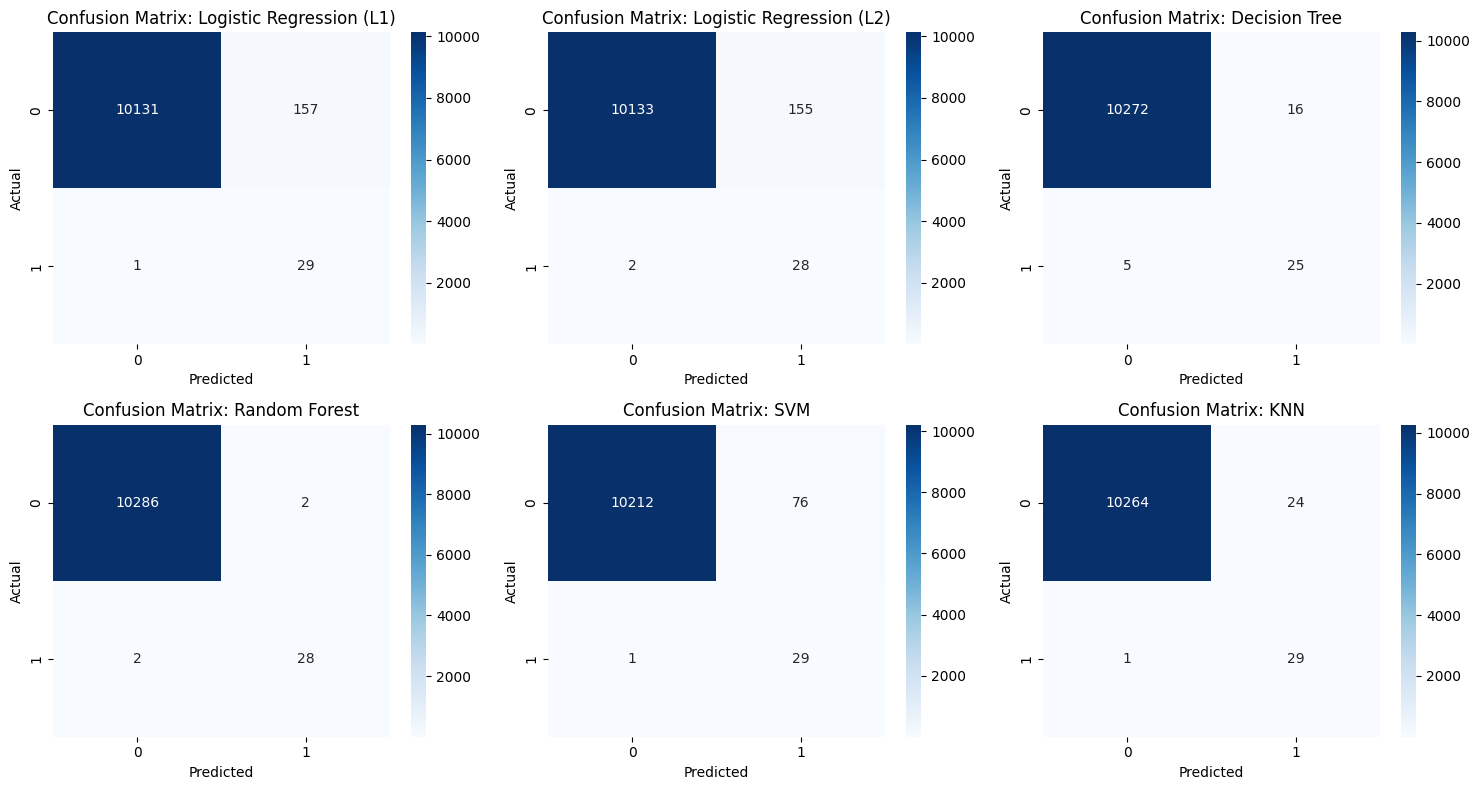

In [ ]:
import math

n_models = len(models)
cols = 3
rows = math.ceil(n_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# 9. COMPARATIVE ANALYSIS
# =========================
results_df = pd.DataFrame(results, columns=["Model", "Precision", "Recall", "F1-score"])

print("\n==============================")
print("COMPARISON TABLE")
print(results_df.sort_values(by="F1-score", ascending=False))


COMPARISON TABLE
                      Model  Precision    Recall  F1-score
3             Random Forest   0.999612  0.999612  0.999612
2             Decision Tree   0.998380  0.997965  0.998122
5                       KNN   0.998586  0.997577  0.997911
4                       SVM   0.997798  0.992537  0.994597
1  Logistic Regression (L2)   0.997341  0.984784  0.990192
0  Logistic Regression (L1)   0.997447  0.984687  0.990158


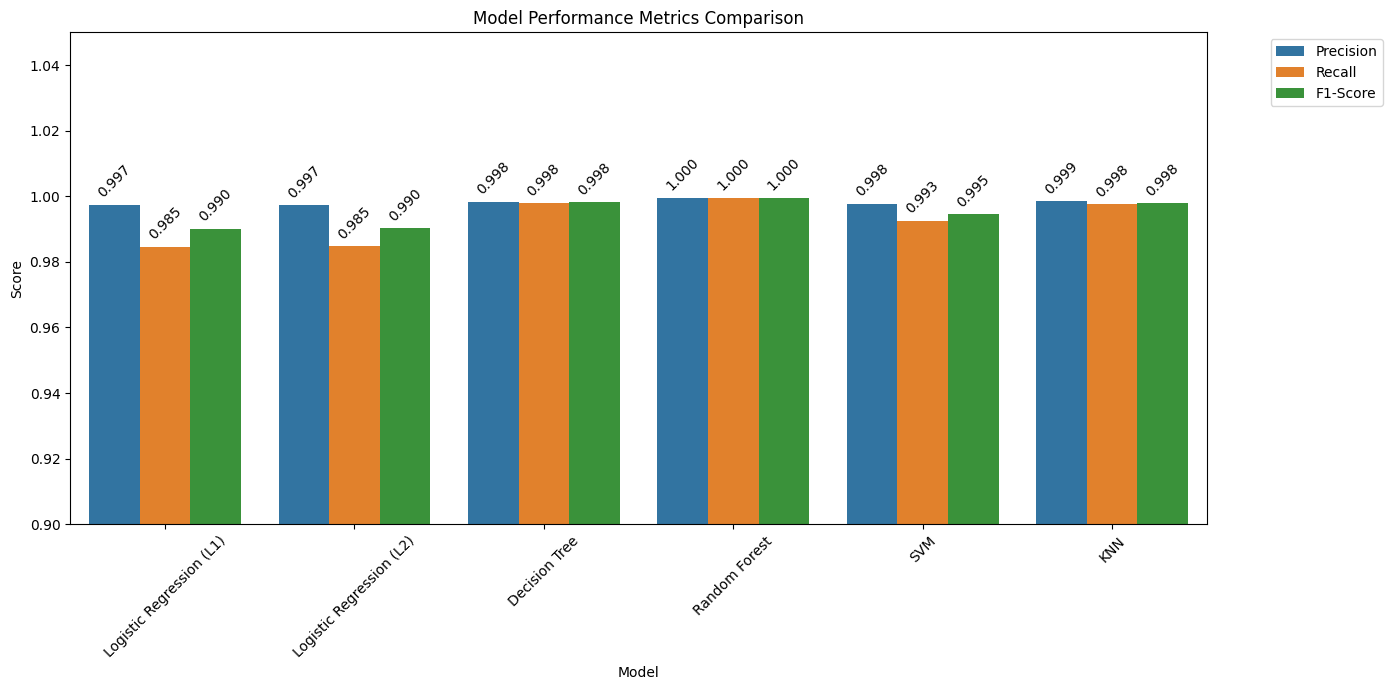

In [ ]:
# Prepare data for plotting
metrics_df = pd.DataFrame(results, columns=['Model', 'Precision', 'Recall', 'F1-Score'])

# Reshape for seaborn
plot_data = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=plot_data, x='Model', y='Score', hue='Metric')


for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, rotation=45)

plt.title('Model Performance Metrics Comparison')
plt.ylim(0.9, 1.05) # Adjusted limit to make room for labels
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

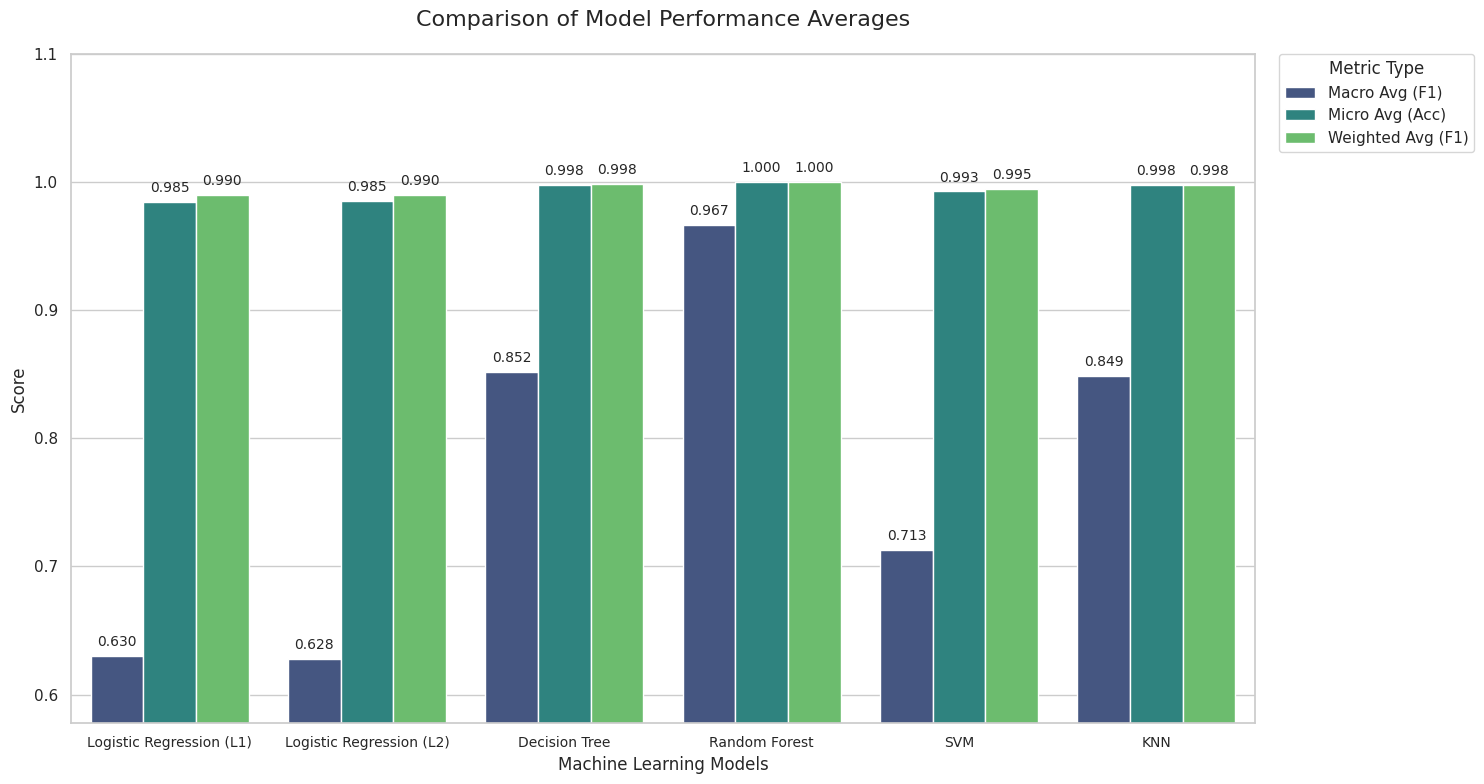

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Using the previously calculated average results
avg_df = pd.DataFrame(avg_results)
plot_avg_data = avg_df.melt(id_vars='Model', var_name='Metric Type', value_name='Score')

# Set aesthetic style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 8))

# Create the bar plot
ax = sns.barplot(data=plot_avg_data, x='Model', y='Score', hue='Metric Type', palette='viridis')

# Add straight value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=5, fontsize=10, rotation=0)

# Aesthetic improvements
plt.title('Comparison of Model Performance Averages', fontsize=16, pad=20)
plt.xlabel('Machine Learning Models', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(min(plot_avg_data['Score']) - 0.05, 1.1)  # Space for labels
plt.xticks(rotation=0, fontsize=10) # Set x-axis labels straight
plt.legend(title='Metric Type', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

In [ ]:
best_model = results_df.sort_values(by="F1-score", ascending=False).iloc[0]
print("\nBest Model Based on F1-score:")
print(best_model)


Best Model Based on F1-score:
Model        Random Forest
Precision         0.999612
Recall            0.999612
F1-score          0.999612
Name: 3, dtype: object


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


df = pd.read_csv('/content/creditcard.csv')

# Features & Target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Take first 1000 features (or all if less)
X = X.iloc[:, :min(1000, X.shape[1])]

# SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SCALING
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# L1 REGULARIZATION MODEL
# =========================
l1_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=1.0,
    max_iter=1000
)

l1_model.fit(X_train, y_train)
y_pred_l1 = l1_model.predict(X_test)

# =========================
# L2 REGULARIZATION MODEL
# =========================
l2_model = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    C=1.0,
    max_iter=1000
)

l2_model.fit(X_train, y_train)
y_pred_l2 = l2_model.predict(X_test)


# EVALUATION

print("\n========== L1 REGULARIZATION ==========")
print(classification_report(y_test, y_pred_l1))

print("\n========== L2 REGULARIZATION ==========")
print(classification_report(y_test, y_pred_l2))



# SHOW FEATURE SELECTION EFFECT


l1_zero_weights = np.sum(l1_model.coef_ == 0)
l2_zero_weights = np.sum(l2_model.coef_ == 0)

print("\n===== FEATURE SELECTION COMPARISON =====")
print("Number of zero coefficients (L1):", l1_zero_weights)
print("Number of zero coefficients (L2):", l2_zero_weights)


========== L1 REGULARIZATION ==========
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962


========== L2 REGULARIZATION ==========
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962


===== FEATURE SELECTION COMPARISON =====
Number of zero coefficients (L1): 1
Number of zero coefficients (L2): 0
